# Generative AI - Assignment 1 working notebook

This notebook implements the questions that are present in the supplied handout.
It deliberately leaves run-specific findings blank until they are produced by the
student's own seeded runs. Run the preflight cells before enabling full training.


## 0. Setup and reproducibility


In [18]:
ROLL = "20L-11327"
RUN_ID = "main_v1"        # Change for every retry, e.g. C3_retry_1
RUN_PREFLIGHT = False      # Preflight must pass before full training
RUN_FULL = True            # Set True only after preflight checks pass
RESUME_RUN = True          # True only when continuing the same RUN_ID after preflight

import csv
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import linalg

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

PACKAGE_ROOT = Path.cwd()

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "torch:", torch.__version__)


def parse_roll(roll):
    if roll == "REPLACE_ME":
        return None
    digits = "".join(ch for ch in roll if ch.isdigit())
    if len(digits) < 4:
        raise ValueError("ROLL must contain at least four digits")
    r = int(digits[-2:])
    seed = int(digits[-4:])
    my_digits = sorted({(r + 3 * k) % 10 for k in range(6)})
    attrs = ["Eyeglasses", "Male", "Young", "Blond_Hair",
             "Wearing_Hat", "Mouth_Slightly_Open"]
    return {
        "roll": roll,
        "R": r,
        "seed": seed,
        "held_out_digit": r % 10,
        "digits": my_digits,
        "attribute": attrs[r % 6],
    }


CONFIG = parse_roll(ROLL)
if CONFIG is None:
    print("Set ROLL before running preflight or training cells.")
    SEED, HELD_OUT_DIGIT, MY_DIGITS, MY_ATTR = 0, None, [], None
else:
    SEED = CONFIG["seed"]
    HELD_OUT_DIGIT = CONFIG["held_out_digit"]
    MY_DIGITS = CONFIG["digits"]
    MY_ATTR = CONFIG["attribute"]
    print(json.dumps(CONFIG, indent=2))

run_folder_name = f"{ROLL}_{RUN_ID}" if CONFIG is not None else "UNCONFIGURED"
ROOT = PACKAGE_ROOT / "runs" / run_folder_name
existing_evidence = (ROOT.exists() and any(
    path.is_file() and path.name != "run_config.json"
    for category in ["logs", "figures", "ckpt", "samples"]
    for path in (ROOT / category).glob("*")
))
if (RUN_PREFLIGHT or RUN_FULL) and existing_evidence and not RESUME_RUN:
    raise RuntimeError(
        f"Run directory already exists: {ROOT}. Choose a new RUN_ID, or set "
        "RESUME_RUN=True only to continue this exact run after preflight."
    )
for folder in ["data", "logs", "figures", "ckpt", "samples", "viva"]:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
print("run directory:", ROOT)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def require_roll():
    if CONFIG is None:
        raise RuntimeError("Enter the real ROLL value first")


set_seed()

RUN_CONFIG_PATH = ROOT / "run_config.json"
if CONFIG is not None:
    run_config_data = (json.loads(RUN_CONFIG_PATH.read_text())
                       if RUN_CONFIG_PATH.exists() and RESUME_RUN else {})
    run_config_data.update({
        **CONFIG,
        "run_id": RUN_ID,
        "device": DEV,
        "torch_version": torch.__version__,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "result_policy": "all reported values must come from saved run artifacts",
        "seed_offsets": {
            "A1": 10, "B1": 20, "classifier": 30,
            "C_runs": 0, "B1_test_noise": 101,
            "C1_samples": 301, "C3_samples": 303,
            "D1_samples": 401, "D2_samples": 402,
            "E_real_test": 701, "E_real_train": 702,
            "E3_real_test": 703, "E3_noise": 909,
        },
    })
    RUN_CONFIG_PATH.write_text(json.dumps(run_config_data, indent=2))


device: cuda torch: 2.11.0+cu128
{
  "roll": "20L-11327",
  "R": 27,
  "seed": 1327,
  "held_out_digit": 7,
  "digits": [
    0,
    2,
    3,
    6,
    7,
    9
  ],
  "attribute": "Blond_Hair"
}
run directory: /content/runs/20L-11327_main_v1


### 0.1 Evidence helpers


In [19]:
METRICS_PATH = ROOT / "metrics.json"
METRICS = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}


def record(key, value):
    """Store a measured value. Call this only with a value produced by a run."""
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (np.floating, np.integer)):
        value = value.item()
    METRICS[key] = value
    METRICS_PATH.write_text(json.dumps(METRICS, indent=2, default=float))
    print(f"{key} = {value}")


def save_rows(path, fieldnames, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def append_diary(run_id, planned, observation="TO BE POPULATED BY RUN",
                 check="TO BE POPULATED BY RUN", action="none",
                 outcome="TO BE POPULATED BY RUN"):
    path = ROOT / "viva" / "experiment-diary.md"
    with path.open("a", encoding="utf-8") as f:
        f.write(f"\n## Run ID: {run_id}\n\n")
        f.write(f"- Planned settings: {planned}\n")
        f.write(f"- Observation: {observation}\n")
        f.write(f"- Check performed: {check}\n")
        f.write(f"- Action taken: {action}\n")
        f.write(f"- Outcome and evidence: {outcome}\n")


def first_grad_norm(module):
    for parameter in module.parameters():
        if parameter.grad is not None:
            return parameter.grad.detach().norm(2).item()
    return 0.0


def full_grad_norm(module):
    squares = [p.grad.detach().pow(2).sum() for p in module.parameters()
               if p.grad is not None]
    return torch.sqrt(torch.stack(squares).sum()).item() if squares else 0.0


def finite_check(name, value):
    value = float(value)
    if not math.isfinite(value):
        raise FloatingPointError(f"{name} is not finite: {value}")


def require_overfit_drop(name, losses, minimum_fraction=0.10):
    values = np.asarray(losses, dtype=float)
    if not np.isfinite(values).all():
        raise FloatingPointError(f"{name} preflight contains NaN/Inf")
    required = values[0] * (1 - minimum_fraction)
    if values[-1] >= required:
        raise RuntimeError(
            f"{name} ten-image overfit did not reduce loss by at least "
            f"{minimum_fraction:.0%}: {values[0]:.6g} -> {values[-1]:.6g}"
        )


def describe_tensor(name, tensor):
    x = tensor.detach().float()
    print(name, "shape=", tuple(x.shape), "dtype=", tensor.dtype,
          "range=", (x.min().item(), x.max().item()),
          "mean=", x.mean().item())


def model_size(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def save_checkpoint(name, model, config, **extra):
    torch.save({
        "model_state": model.state_dict(),
        "config": config,
        "roll_config": CONFIG,
        **extra,
    }, ROOT / "ckpt" / f"{name}.pt")
    if RUN_CONFIG_PATH.exists():
        run_config = json.loads(RUN_CONFIG_PATH.read_text())
        run_config.setdefault("experiments", {})[name] = config
        RUN_CONFIG_PATH.write_text(json.dumps(run_config, indent=2))


def show_grid(imgs, nrow=8, title=None, save=None, figsize=(10, 4)):
    x = imgs.detach().cpu().float()
    if x.min() < -0.01:
        x = (x + 1) / 2
    grid = torchvision.utils.make_grid(x.clamp(0, 1), nrow=nrow,
                                       padding=2, pad_value=1)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).squeeze(),
               cmap="gray" if grid.shape[0] == 1 else None)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=160, bbox_inches="tight")
    plt.show()


def save_stacked_rows(rows, labels, path, nrow=8):
    """rows is a list of equally sized image tensors."""
    fig, axes = plt.subplots(len(rows), 1, figsize=(12, 2.2 * len(rows)))
    if len(rows) == 1:
        axes = [axes]
    for ax, images, label in zip(axes, rows, labels):
        x = images.detach().cpu().float()
        if x.min() < -0.01:
            x = (x + 1) / 2
        grid = torchvision.utils.make_grid(x.clamp(0, 1), nrow=nrow,
                                           padding=2, pad_value=1)
        ax.imshow(grid.permute(1, 2, 0).squeeze(),
                  cmap="gray" if grid.shape[0] == 1 else None)
        ax.set_title(label)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


## 1. Data


In [20]:
mnist_tf = transforms.ToTensor()


def subset_by_digits(dataset, digits):
    indices = [i for i, y in enumerate(dataset.targets.tolist()) if y in digits]
    return Subset(dataset, indices)


class RemappedDigits(Dataset):
    def __init__(self, dataset, digits):
        self.dataset = dataset
        self.digits = list(digits)
        self.mapping = {digit: i for i, digit in enumerate(self.digits)}
        self.indices = [i for i, y in enumerate(dataset.targets.tolist())
                        if y in self.mapping]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.dataset[self.indices[i]]
        return x, self.mapping[int(y)]


class UInt8ImageDataset(Dataset):
    def __init__(self, images_uint8):
        self.images = images_uint8

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        return self.images[i].float() / 255.0


celeba_tf = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

CELEBA_ATTRIBUTES = ["Smiling", "Eyeglasses", "Male", "Young", "Blond_Hair",
                     "Wearing_Hat", "Mouth_Slightly_Open"]


def prepare_celeba_cache(n_images=30000):
    """Cache resized images as uint8 to keep Colab memory/disk use reasonable."""
    require_roll()
    cache_path = PACKAGE_ROOT / "data" / "celeba_30k_allattrs_uint8.pt"
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists():
        print("loading", cache_path)
        package = torch.load(cache_path, map_location="cpu", weights_only=False)
        missing = set(CELEBA_ATTRIBUTES) - set(package.get("attrs", {}))
        if missing:
            raise RuntimeError(f"CelebA cache is missing attributes: {sorted(missing)}")
        return package

    try:
        import kagglehub
        base = Path(kagglehub.dataset_download("jessicali9530/celeba-dataset"))
        image_root = base / "img_align_celeba" / "img_align_celeba"
        frame = pd.read_csv(base / "list_attr_celeba.csv").iloc[:n_images]
        images = []
        for filename in frame["image_id"]:
            with Image.open(image_root / filename).convert("RGB") as image:
                images.append((celeba_tf(image) * 255).round().to(torch.uint8))
        attrs = {name: (frame[name].to_numpy() == 1) for name in CELEBA_ATTRIBUTES}
    except Exception as error:
        print("kagglehub path failed:", error)
        dataset = torchvision.datasets.CelebA(
            ROOT / "data", split="train", download=True,
            transform=celeba_tf, target_type="attr")
        name_to_col = {name: i for i, name in enumerate(dataset.attr_names)}
        images = []
        attribute_values = {name: [] for name in CELEBA_ATTRIBUTES}
        for i in range(min(n_images, len(dataset))):
            image, attr = dataset[i]
            images.append((image * 255).round().to(torch.uint8))
            for name in CELEBA_ATTRIBUTES:
                attribute_values[name].append(bool(attr[name_to_col[name]].item() == 1))
        attrs = {name: np.array(values) for name, values in attribute_values.items()}

    package = {"images": torch.stack(images), "attrs": attrs,
               "attribute_names": CELEBA_ATTRIBUTES, "n_images": len(images)}
    torch.save(package, cache_path)
    return package


def make_fixed_split(n, val_fraction=0.1, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    order = torch.randperm(n, generator=generator).tolist()
    n_val = int(n * val_fraction)
    val_idx, train_idx = order[:n_val], order[n_val:]
    np.save(ROOT / "data" / "celeba_train_indices.npy", np.array(train_idx))
    np.save(ROOT / "data" / "celeba_val_indices.npy", np.array(val_idx))
    return train_idx, val_idx


if RUN_PREFLIGHT or RUN_FULL:
    require_roll()
    mnist_tr = torchvision.datasets.MNIST(ROOT / "data", train=True,
                                           download=True, transform=mnist_tf)
    mnist_te = torchvision.datasets.MNIST(ROOT / "data", train=False,
                                           download=True, transform=mnist_tf)
    celeba_package = prepare_celeba_cache()
    celeba_ds = UInt8ImageDataset(celeba_package["images"])
    celeba_attr = celeba_package["attrs"]
    celeba_train_idx, celeba_val_idx = make_fixed_split(len(celeba_ds))
    celeba_train = Subset(celeba_ds, celeba_train_idx)
    celeba_val = Subset(celeba_ds, celeba_val_idx)
    print("CelebA:", len(celeba_train), "train", len(celeba_val), "validation")
    print("Smiling counts:", np.bincount(np.asarray(celeba_attr["Smiling"], int)))
    print(MY_ATTR, "counts:", np.bincount(np.asarray(celeba_attr[MY_ATTR], int)))
    print("MNIST assigned digits:", MY_DIGITS)


loading /content/data/celeba_30k_allattrs_uint8.pt
CelebA: 27000 train 3000 validation
Smiling counts: [15741 14259]
Blond_Hair counts: [25599  4401]
MNIST assigned digits: [0, 2, 3, 6, 7, 9]


## 2. Part A - AE and VAE


ae {'epoch': 1, 'train_pixel_mse': 0.019759789962827422, 'train_kl_per_image': 0.0, 'train_scaled_total': 0.019759789962827422, 'val_pixel_mse': 0.010721491482522752, 'val_kl_per_image': 0.0, 'val_scaled_total': 0.010721491482522752}
ae {'epoch': 2, 'train_pixel_mse': 0.009380036137722156, 'train_kl_per_image': 0.0, 'train_scaled_total': 0.009380036137722156, 'val_pixel_mse': 0.008305500944455464, 'val_kl_per_image': 0.0, 'val_scaled_total': 0.008305500944455464}
ae {'epoch': 3, 'train_pixel_mse': 0.007935911923278997, 'train_kl_per_image': 0.0, 'train_scaled_total': 0.007935911923278997, 'val_pixel_mse': 0.007402867529127333, 'val_kl_per_image': 0.0, 'val_scaled_total': 0.007402867529127333}
ae {'epoch': 4, 'train_pixel_mse': 0.007521308113027502, 'train_kl_per_image': 0.0, 'train_scaled_total': 0.007521308113027502, 'val_pixel_mse': 0.007533604317241245, 'val_kl_per_image': 0.0, 'val_scaled_total': 0.007533604317241245}
ae {'epoch': 5, 'train_pixel_mse': 0.007224109764452334, 'train_

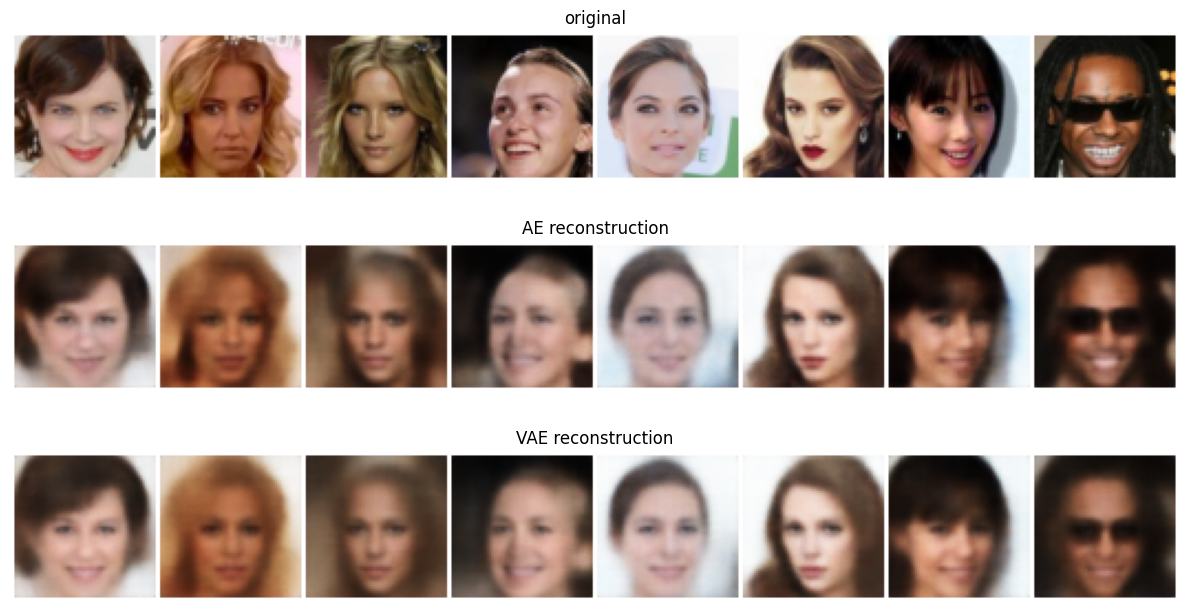

In [21]:
LATENT = 64


class ConvEncoder(nn.Module):
    def __init__(self, out_dim, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], 3
        for c_out in channels:
            layers.extend([
                nn.Conv2d(c_in, c_out, 4, 2, 1),
                nn.BatchNorm2d(c_out),
                nn.LeakyReLU(0.2, inplace=True),
            ])
            c_in = c_out
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1] * 4 * 4, out_dim)

    def forward(self, x):
        return self.head(self.body(x).flatten(1))


class ConvDecoder(nn.Module):
    def __init__(self, in_dim, channels=(256, 128, 64, 32)):
        super().__init__()
        self.c0 = channels[0]
        self.fc = nn.Linear(in_dim, channels[0] * 4 * 4)
        layers = []
        for c_in, c_out in zip(channels, channels[1:]):
            layers.extend([
                nn.ConvTranspose2d(c_in, c_out, 4, 2, 1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            ])
        layers.extend([nn.ConvTranspose2d(channels[-1], 3, 4, 2, 1), nn.Sigmoid()])
        self.body = nn.Sequential(*layers)

    def forward(self, z):
        return self.body(self.fc(z).view(-1, self.c0, 4, 4))


class AE(nn.Module):
    def __init__(self, d=LATENT):
        super().__init__()
        self.enc = ConvEncoder(d)
        self.dec = ConvDecoder(d)

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z


class VAE(nn.Module):
    def __init__(self, d=LATENT):
        super().__init__()
        self.enc = ConvEncoder(2 * d)
        self.dec = ConvDecoder(d)
        self.d = d

    def encode(self, x):
        h = self.enc(x)
        return h[:, :self.d], h[:, self.d:]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.dec(z), mu, logvar


def kl_term(mu, logvar):
    return 0.5 * (logvar.exp() + mu.pow(2) - 1.0 - logvar).sum(1).mean()


def reconstruction_epoch(model, loader, optimizer=None, vae=False):
    training = optimizer is not None
    model.train(training)
    total_sse, total_kl, n_images = 0.0, 0.0, 0
    for x in loader:
        x = x.to(DEV)
        if training:
            optimizer.zero_grad(set_to_none=True)
        if vae:
            mu, logvar = model.encode(x)
            if training:
                z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
            else:
                z = mu
            recon = model.dec(z)
            kl = kl_term(mu, logvar)
        else:
            recon, _ = model(x)
            kl = torch.zeros((), device=DEV)
        # ELBO divided by the fixed pixel count: same optimum, readable scale.
        pixel_mse = F.mse_loss(recon, x, reduction="mean")
        loss = pixel_mse + kl / x[0].numel()
        if training:
            loss.backward()
            optimizer.step()
        total_sse += F.mse_loss(recon, x, reduction="sum").item()
        total_kl += kl.item() * len(x)
        n_images += len(x)
    return {
        "pixel_mse": total_sse / (n_images * 3 * 64 * 64),
        "kl_per_image": total_kl / n_images,
        "scaled_total": (total_sse + total_kl) / (n_images * 3 * 64 * 64),
    }


def overfit_reconstruction(model, images, vae=False, steps=100, lr=1e-3):
    set_seed(SEED + 1010 + int(vae))
    model = model.to(DEV)
    x = images[:10].to(DEV)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    trace = []
    model.train()
    for step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        if vae:
            mu, _ = model.encode(x)
            recon = model.dec(mu)
            loss = F.mse_loss(recon, x)
        else:
            recon, _ = model(x)
            loss = F.mse_loss(recon, x)
        loss.backward()
        gradient = full_grad_norm(model)
        finite_check("reconstruction preflight loss", loss.item())
        if gradient <= 0 or not math.isfinite(gradient):
            raise RuntimeError("reconstruction preflight has invalid gradients")
        optimizer.step()
        trace.append({"step": step, "loss": loss.item(), "gradient_norm": gradient})
    return trace


def train_a1(epochs=10, batch_size=64, lr=1e-3):
    set_seed(SEED + 10)
    loader_generator = torch.Generator().manual_seed(SEED + 10)
    train_loader = DataLoader(celeba_train, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=(DEV == "cuda"),
                              generator=loader_generator)
    val_loader = DataLoader(celeba_val, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=(DEV == "cuda"))
    models = {"ae": AE().to(DEV), "vae": VAE().to(DEV)}
    histories = {}
    for name, model in models.items():
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        rows = []
        for epoch in range(1, epochs + 1):
            train_stats = reconstruction_epoch(model, train_loader, optimizer,
                                               vae=(name == "vae"))
            with torch.no_grad():
                val_stats = reconstruction_epoch(model, val_loader, vae=(name == "vae"))
            row = {"epoch": epoch}
            row.update({f"train_{k}": v for k, v in train_stats.items()})
            row.update({f"val_{k}": v for k, v in val_stats.items()})
            rows.append(row)
            print(name, row)
        save_rows(ROOT / "logs" / f"A1_{name}.csv", list(rows[0]), rows)
        save_checkpoint(name, model, {"epochs": epochs, "batch_size": batch_size,
                                     "lr": lr, "latent": LATENT})
        histories[name] = rows

    for name in ["ae", "vae"]:
        final = histories[name][-1]
        record(f"A1_{name}_train_mse", final["train_pixel_mse"])
        record(f"A1_{name}_val_mse", final["val_pixel_mse"])

    fixed = torch.stack([celeba_val[i] for i in range(8)]).to(DEV)
    models["ae"].eval(); models["vae"].eval()
    with torch.no_grad():
        ae_recon = models["ae"](fixed)[0]
        mu, _ = models["vae"].encode(fixed)
        vae_recon = models["vae"].dec(mu)
    save_stacked_rows([fixed, ae_recon, vae_recon],
                      ["original", "AE reconstruction", "VAE reconstruction"],
                      ROOT / "figures" / "A1_recon.png", nrow=8)
    return models["ae"], models["vae"], histories


if RUN_PREFLIGHT:
    require_roll()
    batch = torch.stack([celeba_train[i] for i in range(10)])
    describe_tensor("CelebA preflight", batch)
    ae_test, vae_test = AE().to(DEV), VAE().to(DEV)
    print("AE params", model_size(ae_test), "VAE params", model_size(vae_test))
    with torch.no_grad():
        ae_out, ae_z = ae_test(batch.to(DEV))
        vae_out, vae_mu, vae_logvar = vae_test(batch.to(DEV))
    print("AE shapes:", tuple(batch.shape), tuple(ae_z.shape), tuple(ae_out.shape))
    print("VAE shapes:", tuple(vae_mu.shape), tuple(vae_logvar.shape), tuple(vae_out.shape))
    ae_trace = overfit_reconstruction(ae_test, batch)
    vae_trace = overfit_reconstruction(vae_test, batch, vae=True)
    save_rows(ROOT / "logs" / "preflight_ae_overfit.csv",
              ["step", "loss", "gradient_norm"], ae_trace)
    save_rows(ROOT / "logs" / "preflight_vae_overfit.csv",
              ["step", "loss", "gradient_norm"], vae_trace)
    require_overfit_drop("AE", [row["loss"] for row in ae_trace])
    require_overfit_drop("VAE reconstruction path", [row["loss"] for row in vae_trace])
    print("AE overfit start/end", ae_trace[0]["loss"], ae_trace[-1]["loss"])
    print("VAE overfit start/end", vae_trace[0]["loss"], vae_trace[-1]["loss"])


if RUN_FULL:
    ae, vae, a1_history = train_a1()


### A2. VAE interpolation


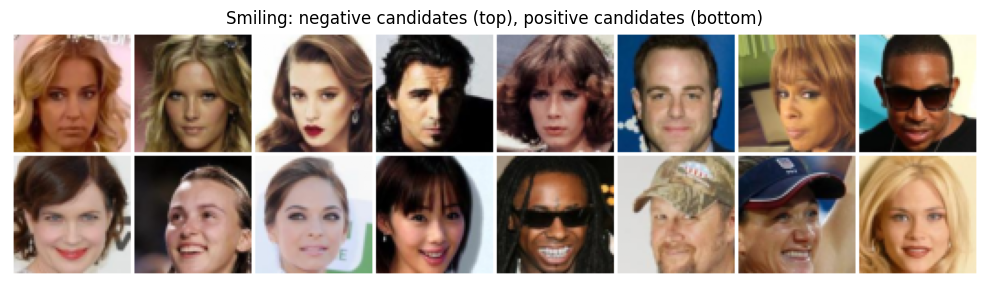

Smiling negative indices [22017, 10502, 26676, 29984, 5549, 10605, 4411, 17549] positive indices [2816, 2208, 12355, 22869, 29817, 2989, 15023, 4857]


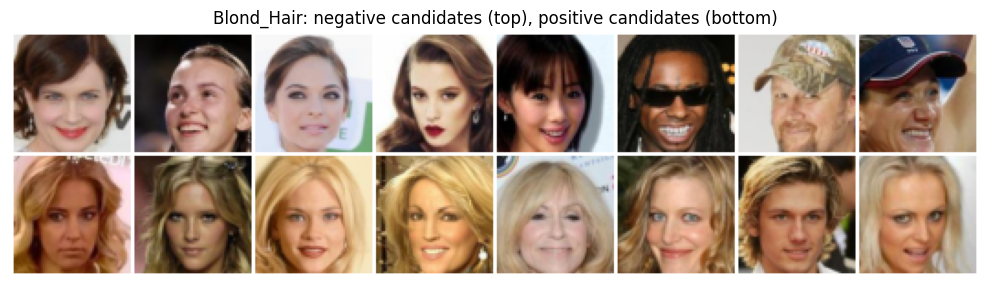

Blond_Hair negative indices [2816, 2208, 12355, 26676, 22869, 29817, 2989, 15023] positive indices [22017, 10502, 4857, 3984, 93, 12888, 16732, 17267]


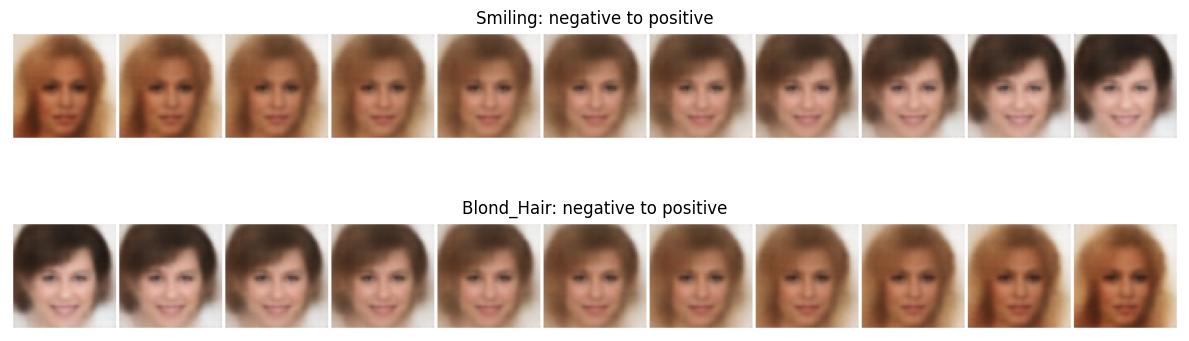

Write only observations visible in the saved strips.


In [22]:
@torch.no_grad()
def interpolate(decoder, z1, z2, n=11):
    t = torch.linspace(0, 1, n, device=z1.device).view(-1, 1)
    return decoder((1 - t) * z1.view(1, -1) + t * z2.view(1, -1)), t.flatten()


def find_attribute_endpoints(attribute, candidate_indices):
    values = np.asarray(celeba_attr[attribute], dtype=bool)
    positive = next(i for i in candidate_indices if values[i])
    negative = next(i for i in candidate_indices if not values[i])
    return positive, negative


def show_attribute_candidates(attribute, candidate_indices, per_group=8):
    values = np.asarray(celeba_attr[attribute], dtype=bool)
    positive = [i for i in candidate_indices if values[i]][:per_group]
    negative = [i for i in candidate_indices if not values[i]][:per_group]
    images = torch.stack([celeba_ds[i] for i in negative + positive])
    show_grid(images, nrow=per_group,
              title=f"{attribute}: negative candidates (top), positive candidates (bottom)",
              save=ROOT / "figures" / f"A2_{attribute}_candidates.png")
    print(attribute, "negative indices", negative, "positive indices", positive)


# After inspecting the candidate grids, put clearer (negative, positive) indices here.
# Leaving an attribute absent uses the first labelled negative and positive examples.
A2_ENDPOINT_OVERRIDES = {}


def run_a2(vae, endpoint_overrides=None):
    vae.eval()
    endpoint_overrides = endpoint_overrides or {}
    strips, endpoint_rows = [], []
    for attribute in ["Smiling", MY_ATTR]:
        if attribute in endpoint_overrides:
            neg, pos = endpoint_overrides[attribute]
        else:
            pos, neg = find_attribute_endpoints(attribute, celeba_val_idx)
        x = torch.stack([celeba_ds[neg], celeba_ds[pos]]).to(DEV)
        with torch.no_grad():
            mu, _ = vae.encode(x)
            strip, t = interpolate(vae.dec, mu[0], mu[1])
        strips.append(strip)
        endpoint_rows.append({"attribute": attribute, "negative_index": neg,
                              "positive_index": pos, "t_values": t.cpu().tolist()})
    save_stacked_rows(strips, ["Smiling: negative to positive", f"{MY_ATTR}: negative to positive"],
                      ROOT / "figures" / "A2_vae_interp.png", nrow=11)
    (ROOT / "logs" / "A2_endpoints.json").write_text(
        json.dumps(endpoint_rows, indent=2))
    print("Write only observations visible in the saved strips.")


if RUN_FULL:
    show_attribute_candidates("Smiling", celeba_val_idx)
    show_attribute_candidates(MY_ATTR, celeba_val_idx)
    run_a2(vae, A2_ENDPOINT_OVERRIDES)


### A3. Prior samples


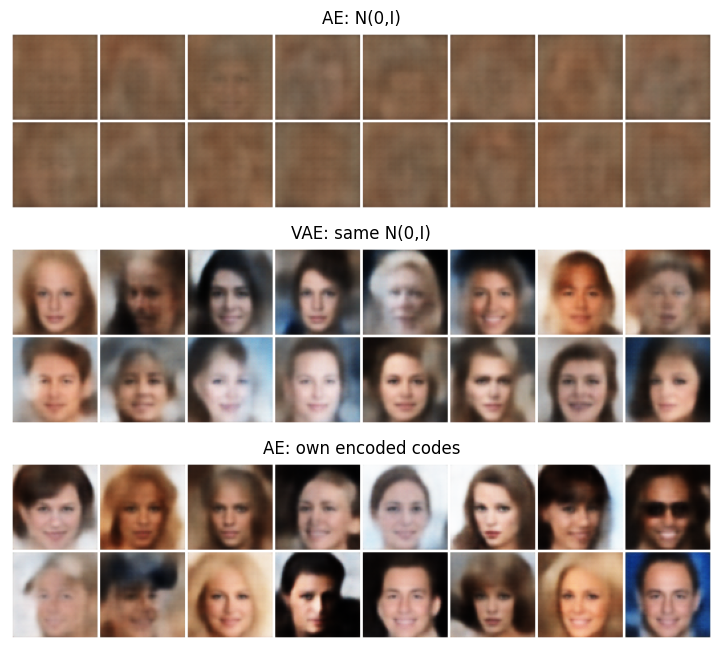

In [23]:
def run_a3(ae, vae):
    set_seed()
    z = torch.randn(16, LATENT, device=DEV)
    real = torch.stack([celeba_val[i] for i in range(16)]).to(DEV)
    ae.eval(); vae.eval()
    with torch.no_grad():
        ae_prior = ae.dec(z)
        vae_prior = vae.dec(z)
        ae_own = ae.dec(ae.enc(real))
    torch.save(z.cpu(), ROOT / "samples" / "A3_shared_z.pt")
    save_stacked_rows([ae_prior, vae_prior, ae_own],
                      ["AE: N(0,I)", "VAE: same N(0,I)", "AE: own encoded codes"],
                      ROOT / "figures" / "A3_prior_samples.png", nrow=8)


if RUN_FULL:
    run_a3(ae, vae)
    append_diary("A1", "same-backbone AE/VAE reconstruction comparison")
    append_diary("A2", "mean-code interpolation for Smiling and assigned attribute")
    append_diary("A3", "shared N(0,I) samples and AE own-code sanity row")


## 3. Part B - Denoising AE


{'epoch': 1, 'train_mse': 0.044473765459656714, 'val_mse': 0.024268783628940582}
{'epoch': 2, 'train_mse': 0.020310813511411348, 'val_mse': 0.017700092867016792}
{'epoch': 3, 'train_mse': 0.01612450488557418, 'val_mse': 0.015312546864151955}
{'epoch': 4, 'train_mse': 0.014268477974335352, 'val_mse': 0.013755423948168755}
{'epoch': 5, 'train_mse': 0.01302237224082152, 'val_mse': 0.01271943561732769}
B1_psnr_noisy = 13.320408821105957
B1_psnr_denoised = 19.444652557373047


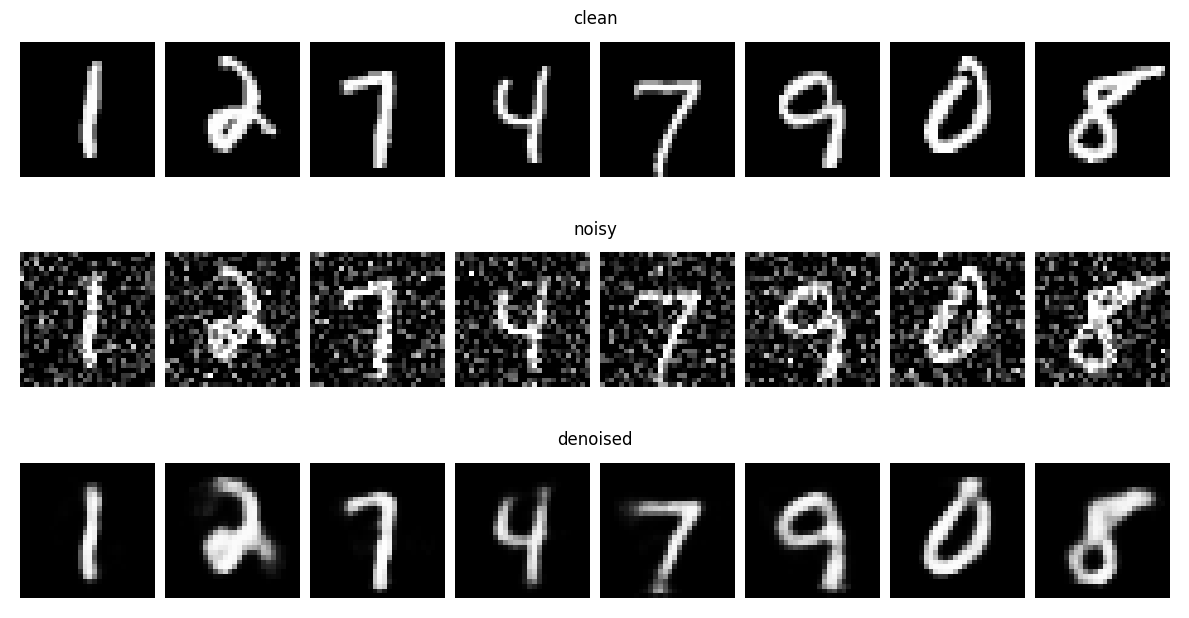

In [24]:
def psnr(a, b, data_range=1.0):
    mse = ((a - b) ** 2).flatten(1).mean(1).clamp_min(1e-12)
    return (10 * torch.log10(data_range ** 2 / mse)).mean().item()


class SmallAE(nn.Module):
    def __init__(self, d=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(784, 256),
                                 nn.ReLU(inplace=True), nn.Linear(256, d))
        self.dec = nn.Sequential(nn.Linear(d, 256), nn.ReLU(inplace=True),
                                 nn.Linear(256, 784), nn.Sigmoid(),
                                 nn.Unflatten(1, (1, 28, 28)))

    def forward(self, x):
        return self.dec(self.enc(x))


def add_noise(x, sigma=0.3, generator=None):
    noise = torch.randn(x.shape, generator=generator, device=x.device, dtype=x.dtype)
    return (x + sigma * noise).clamp(0, 1)


def train_denoiser(epochs=5, batch_size=128, lr=1e-3):
    set_seed(SEED + 20)
    loader_generator = torch.Generator().manual_seed(SEED + 20)
    loader = DataLoader(mnist_tr, batch_size=batch_size, shuffle=True,
                        generator=loader_generator)
    model = SmallAE().to(DEV)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    val_clean = torch.stack([mnist_te[i][0] for i in range(1000)]).to(DEV)
    val_generator = torch.Generator(device=DEV).manual_seed(SEED + 121)
    val_noisy = add_noise(val_clean, generator=val_generator)
    rows = []
    for epoch in range(1, epochs + 1):
        model.train()
        total, count = 0.0, 0
        for clean, _ in loader:
            clean = clean.to(DEV)
            noisy = add_noise(clean)
            optimizer.zero_grad(set_to_none=True)
            denoised = model(noisy)
            loss = F.mse_loss(denoised, clean)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(clean)
            count += len(clean)
        model.eval()
        with torch.no_grad():
            val_mse = F.mse_loss(model(val_noisy), val_clean).item()
        rows.append({"epoch": epoch, "train_mse": total / count,
                     "val_mse": val_mse})
        print(rows[-1])
    save_rows(ROOT / "logs" / "B1_denoise.csv", list(rows[0]), rows)
    save_checkpoint("B1_denoiser", model,
                    {"epochs": epochs, "batch_size": batch_size, "lr": lr,
                     "noise_sigma": 0.3})

    test_indices = np.random.default_rng(SEED).choice(len(mnist_te), 1000, replace=False)
    np.save(ROOT / "data" / "B1_test_indices.npy", test_indices)
    clean = torch.stack([mnist_te[int(i)][0] for i in test_indices]).to(DEV)
    generator = torch.Generator(device=DEV).manual_seed(SEED + 101)
    noisy = add_noise(clean, generator=generator)
    model.eval()
    with torch.no_grad():
        denoised = model(noisy)
    noisy_psnr = psnr(noisy, clean)
    denoised_psnr = psnr(denoised, clean)
    record("B1_psnr_noisy", noisy_psnr)
    record("B1_psnr_denoised", denoised_psnr)
    save_stacked_rows([clean[:8], noisy[:8], denoised[:8]],
                      ["clean", "noisy", "denoised"],
                      ROOT / "figures" / "B1_denoise.png", nrow=8)
    return model


def overfit_denoiser(images, steps=100):
    set_seed(SEED + 1020)
    model = SmallAE().to(DEV)
    clean = images[:10].to(DEV)
    generator = torch.Generator(device=DEV).manual_seed(SEED + 11)
    noisy = add_noise(clean, generator=generator)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    trace = []
    for step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        loss = F.mse_loss(model(noisy), clean)
        loss.backward()
        gradient = full_grad_norm(model)
        finite_check("denoiser preflight loss", loss.item())
        if gradient <= 0 or not math.isfinite(gradient):
            raise RuntimeError("denoiser preflight has invalid gradients")
        optimizer.step()
        trace.append(loss.item())
    return trace


if RUN_PREFLIGHT:
    ten_mnist = torch.stack([mnist_tr[i][0] for i in range(10)])
    denoiser_shape_test = SmallAE().to(DEV)
    with torch.no_grad():
        print("denoiser shapes:", tuple(ten_mnist.shape),
              tuple(denoiser_shape_test(ten_mnist.to(DEV)).shape))
    trace = overfit_denoiser(ten_mnist)
    require_overfit_drop("denoiser", trace)
    save_rows(ROOT / "logs" / "preflight_denoiser_overfit.csv",
              ["step", "loss"], [{"step": i, "loss": loss} for i, loss in enumerate(trace)])
    print("denoiser overfit start/end:", trace[0], trace[-1])


if RUN_FULL:
    denoiser = train_denoiser()
    append_diary("B1", "SmallAE, sigma=0.3 noisy input, clean target")


## 4. Six-digit classifier


In [25]:
class MnistCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(inplace=True))
        self.head = nn.Linear(128, n_classes)

    def features(self, x):
        return self.conv(x)

    def forward(self, x):
        return self.head(self.features(x))


@torch.no_grad()
def evaluate_classifier(model, loader):
    model.eval()
    correct, total = 0, 0
    confusion = np.zeros((len(MY_DIGITS), len(MY_DIGITS)), dtype=int)
    for x, y in loader:
        pred = model(x.to(DEV)).argmax(1).cpu()
        correct += int((pred == y).sum())
        total += len(y)
        for target, guess in zip(y.numpy(), pred.numpy()):
            confusion[target, guess] += 1
    return correct / total, confusion


def train_classifier(minimum_epochs=3, max_epochs=5, batch_size=128, lr=1e-3):
    set_seed(SEED + 30)
    train_ds = RemappedDigits(mnist_tr, MY_DIGITS)
    test_ds = RemappedDigits(mnist_te, MY_DIGITS)
    loader_generator = torch.Generator().manual_seed(SEED + 30)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              generator=loader_generator)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)
    model = MnistCNN(len(MY_DIGITS)).to(DEV)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    rows = []
    for epoch in range(1, max_epochs + 1):
        model.train(); total_loss, count = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(DEV), y.to(DEV)
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(x), y)
            loss.backward(); optimizer.step()
            total_loss += loss.item() * len(x); count += len(x)
        accuracy, _ = evaluate_classifier(model, test_loader)
        rows.append({"epoch": epoch, "train_loss": total_loss / count,
                     "test_accuracy": accuracy})
        print(rows[-1])
        if epoch >= minimum_epochs and accuracy >= 0.97:
            break
    accuracy, confusion = evaluate_classifier(model, test_loader)
    save_rows(ROOT / "logs" / "classifier.csv", list(rows[0]), rows)
    pd.DataFrame(confusion, index=MY_DIGITS, columns=MY_DIGITS).to_csv(
        ROOT / "logs" / "classifier_confusion.csv", index_label="true_digit")
    save_checkpoint("clf", model,
                    {"minimum_epochs": minimum_epochs, "max_epochs": max_epochs,
                     "actual_epochs": len(rows), "batch_size": batch_size,
                     "lr": lr, "digits": MY_DIGITS})
    record("classifier_test_accuracy", accuracy)
    if accuracy < 0.97:
        raise RuntimeError(
            f"Classifier accuracy {accuracy:.4f} is below 97%. Inspect the confusion "
            "matrix and training log before running C3/D/E."
        )
    return model


def overfit_classifier(dataset, steps=100):
    set_seed(SEED + 1030)
    model = MnistCNN(len(MY_DIGITS)).to(DEV)
    x = torch.stack([dataset[i][0] for i in range(10)]).to(DEV)
    y = torch.tensor([dataset[i][1] for i in range(10)], device=DEV)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    trace = []
    for step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        gradient = full_grad_norm(model)
        finite_check("classifier preflight loss", loss.item())
        if gradient <= 0 or not math.isfinite(gradient):
            raise RuntimeError("classifier preflight has invalid gradients")
        optimizer.step()
        trace.append(loss.item())
    return trace


if RUN_PREFLIGHT:
    remapped_train = RemappedDigits(mnist_tr, MY_DIGITS)
    classifier_shape_test = MnistCNN(len(MY_DIGITS)).to(DEV)
    with torch.no_grad():
        classifier_x = torch.stack([remapped_train[i][0] for i in range(10)]).to(DEV)
        print("classifier shapes:", tuple(classifier_x.shape),
              tuple(classifier_shape_test.features(classifier_x).shape),
              tuple(classifier_shape_test(classifier_x).shape))
    trace = overfit_classifier(remapped_train)
    require_overfit_drop("classifier", trace)
    save_rows(ROOT / "logs" / "preflight_classifier_overfit.csv",
              ["step", "loss"], [{"step": i, "loss": loss} for i, loss in enumerate(trace)])
    print("classifier overfit start/end:", trace[0], trace[-1])


if RUN_FULL:
    clf = train_classifier()
    append_diary("classifier", "six assigned digits remapped to 0..5")


{'epoch': 1, 'train_loss': 0.1735341783189151, 'test_accuracy': 0.9823832474655144}
{'epoch': 2, 'train_loss': 0.038743003915798296, 'test_accuracy': 0.989529665946485}
{'epoch': 3, 'train_loss': 0.02668575793500592, 'test_accuracy': 0.9901944490609939}
classifier_test_accuracy = 0.9901944490609939


## 5. Parts C and D - GANs


In [26]:
ZDIM = 64


class G28(nn.Module):
    def __init__(self, zdim=ZDIM, channels=128, batchnorm=True):
        super().__init__()
        bn = (lambda c: nn.BatchNorm2d(c)) if batchnorm else (lambda c: nn.Identity())
        self.fc = nn.Sequential(
            nn.Linear(zdim, channels * 7 * 7),
            nn.Unflatten(1, (channels, 7, 7)),
            bn(channels), nn.ReLU(inplace=True))
        self.body = nn.Sequential(
            nn.ConvTranspose2d(channels, channels // 2, 4, 2, 1),
            bn(channels // 2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(channels // 2, 1, 4, 2, 1), nn.Tanh())

    def forward(self, z):
        return self.body(self.fc(z))


class D28(nn.Module):
    def __init__(self, channels=64, batchnorm=False):
        super().__init__()
        middle_norm = nn.BatchNorm2d(channels * 2) if batchnorm else nn.Identity()
        self.body = nn.Sequential(
            nn.Conv2d(1, channels, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels * 2, 4, 2, 1), middle_norm,
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(), nn.Linear(channels * 2 * 7 * 7, 1))

    def forward(self, x):
        return self.body(x)


def to_pm1(x):
    return x * 2 - 1


def to_01(x):
    return (x + 1) / 2


class GANRunLog:
    COLUMNS = ["iter", "d_loss", "g_loss", "D_x", "D_G_z",
               "g_grad_norm", "g_full_grad_norm", "d_steps", "g_steps"]

    def __init__(self, name):
        self.path = ROOT / "logs" / f"{name}.csv"
        self.file = self.path.open("w", newline="")
        self.writer = csv.DictWriter(self.file, fieldnames=self.COLUMNS)
        self.writer.writeheader()
        self.rows = []

    def write(self, **row):
        clean = {key: row[key] for key in self.COLUMNS}
        self.writer.writerow(clean); self.file.flush()
        self.rows.append(clean)

    def close(self):
        self.file.close()
        return pd.DataFrame(self.rows)


def set_requires_grad(model, value):
    for parameter in model.parameters():
        parameter.requires_grad_(value)


def next_real(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        iterator = iter(loader)
        return next(iterator), iterator


def plot_gan_curves(frame, name, probability_labels=True):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(frame["iter"], frame["D_x"], label="D(x)")
    axes[0].plot(frame["iter"], frame["D_G_z"], label="D(G(z))")
    axes[0].set_ylabel("probability" if probability_labels else "critic score")
    axes[0].legend(); axes[0].set_xlabel("iteration")
    axes[1].plot(frame["iter"], frame["g_grad_norm"], label="first layer")
    axes[1].plot(frame["iter"], frame["g_full_grad_norm"], label="full G", alpha=0.75)
    axes[1].set_yscale("log"); axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("gradient norm"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(ROOT / "figures" / f"{name}_curves.png", dpi=160)
    plt.show()


def logistic_gan_run(name, loader, zdim, iterations, d_steps, g_steps,
                     lr_d, lr_g, saturating=False, g_batchnorm=True,
                     d_batchnorm=False, capture_iteration=None,
                     snapshot_points=None):
    set_seed()
    G = G28(zdim=zdim, batchnorm=g_batchnorm).to(DEV)
    D = D28(batchnorm=d_batchnorm).to(DEV)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))
    fixed_z = torch.randn(64, zdim, device=DEV)
    torch.save(fixed_z.cpu(), ROOT / "samples" / f"{name}_fixed_z.pt")
    log = GANRunLog(name)
    real_iterator = iter(loader)
    snapshots = {}
    snapshot_points = snapshot_points or {}
    ref_grad, death_iteration = None, None

    for iteration in range(1, iterations + 1):
        set_requires_grad(D, True)
        for _ in range(d_steps):
            (real, _), real_iterator = next_real(real_iterator, loader)
            real = to_pm1(real.to(DEV))
            z = torch.randn(len(real), zdim, device=DEV)
            fake = G(z).detach()
            opt_d.zero_grad(set_to_none=True)
            real_logits, fake_logits = D(real), D(fake)
            d_loss = F.softplus(-real_logits).mean() + F.softplus(fake_logits).mean()
            d_loss.backward(); opt_d.step()

        set_requires_grad(D, False)
        for _ in range(g_steps):
            z = torch.randn(loader.batch_size, zdim, device=DEV)
            opt_g.zero_grad(set_to_none=True)
            fake_logits = D(G(z))
            g_loss = (-F.softplus(fake_logits).mean() if saturating
                      else F.softplus(-fake_logits).mean())
            g_loss.backward()
            first_norm = first_grad_norm(G.fc)
            all_norm = full_grad_norm(G)
            opt_g.step()
        set_requires_grad(D, True)

        finite_check("d_loss", d_loss.item()); finite_check("g_loss", g_loss.item())
        d_x = torch.sigmoid(real_logits).mean().item()
        d_g_z = torch.sigmoid(fake_logits).mean().item()
        log.write(iter=iteration, d_loss=d_loss.item(), g_loss=g_loss.item(),
                  D_x=d_x, D_G_z=d_g_z, g_grad_norm=first_norm,
                  g_full_grad_norm=all_norm, d_steps=d_steps, g_steps=g_steps)

        if iteration == 100:
            ref_grad = first_norm
        if (ref_grad is not None and death_iteration is None and iteration > 100
                and first_norm < 0.01 * ref_grad):
            death_iteration = iteration
            with torch.no_grad(): snapshots["death"] = G(fixed_z).cpu()
        if capture_iteration is not None and iteration == capture_iteration:
            with torch.no_grad(): snapshots["matched"] = G(fixed_z).cpu()
        if iteration in snapshot_points:
            with torch.no_grad(): snapshots[snapshot_points[iteration]] = G(fixed_z).cpu()

    with torch.no_grad(): snapshots["final"] = G(fixed_z).cpu()
    frame = log.close()
    save_checkpoint(name, G, {"zdim": zdim, "iterations": iterations,
                             "d_steps": d_steps, "g_steps": g_steps,
                             "lr_d": lr_d, "lr_g": lr_g,
                             "saturating": saturating},
                    discriminator_state=D.state_dict())
    plot_gan_curves(frame, name)
    return G, D, frame, snapshots, ref_grad, death_iteration


def save_c1_key_rows(frame, death_iteration):
    rows = []
    for row_type, index in [
        ("reference", 100),
        ("first_crossing", death_iteration),
        ("minimum", int(frame.loc[frame.g_grad_norm.idxmin(), "iter"])),
    ]:
        if index is None:
            rows.append({"run_id": "C1", "row_type": row_type,
                         "iteration": "NO_CROSSING", "source_csv": "logs/C1.csv"})
        else:
            source = frame.loc[frame["iter"] == index].iloc[0]
            row = {
                "run_id": "C1",
                "row_type": row_type,
                "iteration": int(source["iter"]),
                "d_loss": source["d_loss"],
                "g_loss": source["g_loss"],
                "D_x": source["D_x"],
                "D_G_z": source["D_G_z"],
                "g_grad_norm": source["g_grad_norm"],
                "g_full_grad_norm": source["g_full_grad_norm"],
                "source_csv": "logs/C1.csv",
            }
            rows.append(row)
    fields = ["run_id", "row_type", "iteration", "d_loss", "g_loss", "D_x",
              "D_G_z", "g_grad_norm", "g_full_grad_norm", "source_csv"]
    save_rows(ROOT / "viva" / "key_rows.csv", fields, rows)


def gan_smoke_check(loader, zdim=64, steps=20):
    G = G28(zdim=zdim).to(DEV); D = D28().to(DEV)
    real, _ = next(iter(loader)); real = to_pm1(real.to(DEV))
    opt_g = torch.optim.Adam(G.parameters(), lr=2e-4)
    opt_d = torch.optim.Adam(D.parameters(), lr=2e-4)
    rows = []
    for step in range(steps):
        z = torch.randn(len(real), zdim, device=DEV)
        fake = G(z)
        opt_d.zero_grad(set_to_none=True)
        real_logits, fake_logits = D(real), D(fake.detach())
        d_loss = F.softplus(-real_logits).mean() + F.softplus(fake_logits).mean()
        d_loss.backward(); opt_d.step()

        set_requires_grad(D, False)
        opt_g.zero_grad(set_to_none=True)
        generated_logits = D(G(torch.randn(len(real), zdim, device=DEV)))
        g_loss = F.softplus(-generated_logits).mean()
        g_loss.backward()
        grad = full_grad_norm(G)
        opt_g.step(); set_requires_grad(D, True)
        finite_check("smoke d_loss", d_loss.item())
        finite_check("smoke g_loss", g_loss.item())
        rows.append({"step": step, "d_loss": d_loss.item(),
                     "g_loss": g_loss.item(), "g_full_grad_norm": grad})
    save_rows(ROOT / "logs" / "preflight_gan_smoke.csv", list(rows[0]), rows)
    describe_tensor("GAN real", real); describe_tensor("GAN fake", fake)
    print("z", tuple(z.shape), "D(real)", tuple(real_logits.shape),
          "D(fake)", tuple(fake_logits.shape),
          "D/G loss start", rows[0]["d_loss"], rows[0]["g_loss"],
          "D/G loss end", rows[-1]["d_loss"], rows[-1]["g_loss"],
          "G gradient", rows[-1]["g_full_grad_norm"])


if RUN_PREFLIGHT:
    gan_ds = subset_by_digits(mnist_tr, MY_DIGITS)
    gan_loader = DataLoader(gan_ds, batch_size=32, shuffle=True, drop_last=True)
    gan_smoke_check(gan_loader)


### C1. Saturating loss


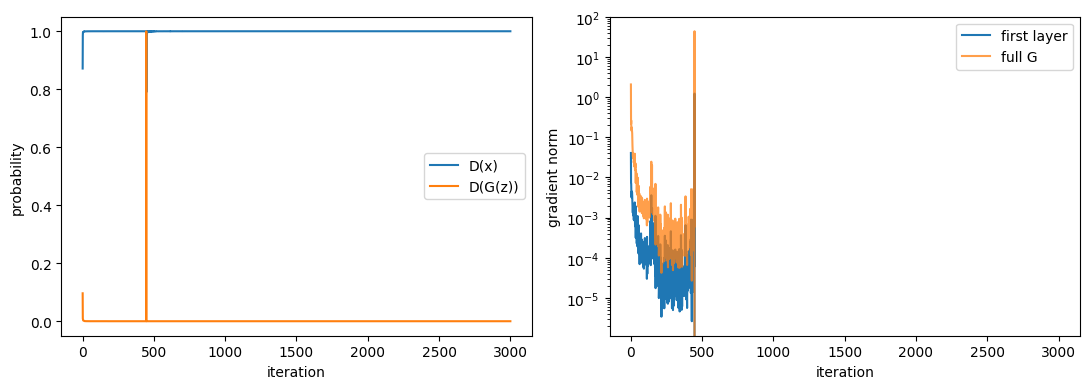

C1_ref_gradnorm_at_100 = 7.021818601060659e-05
C1_iteration_gradient_died = 448


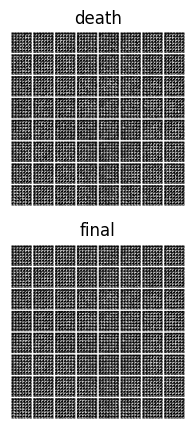

In [27]:
if RUN_FULL:
    gan_ds = subset_by_digits(mnist_tr, MY_DIGITS)
    gan_loader = DataLoader(gan_ds, batch_size=128, shuffle=True, drop_last=True)
    G_C1, D_C1, log_C1, snaps_C1, c1_ref, c1_death = logistic_gan_run(
        "C1", gan_loader, zdim=64, iterations=3000, d_steps=5, g_steps=1,
        lr_d=8e-4, lr_g=2e-4, saturating=True)
    record("C1_ref_gradnorm_at_100", c1_ref)
    record("C1_iteration_gradient_died", c1_death)
    save_c1_key_rows(log_C1, c1_death)
    c1_rows = [snaps_C1[key] for key in ["death", "final"] if key in snaps_C1]
    c1_labels = [key for key in ["death", "final"] if key in snaps_C1]
    save_stacked_rows(c1_rows, c1_labels, ROOT / "figures" / "C1_samples.png")
    append_diary("C1", "saturating G loss, 5 D:G 1, lr_D=8e-4, lr_G=2e-4")


### C2. One-line non-saturating change


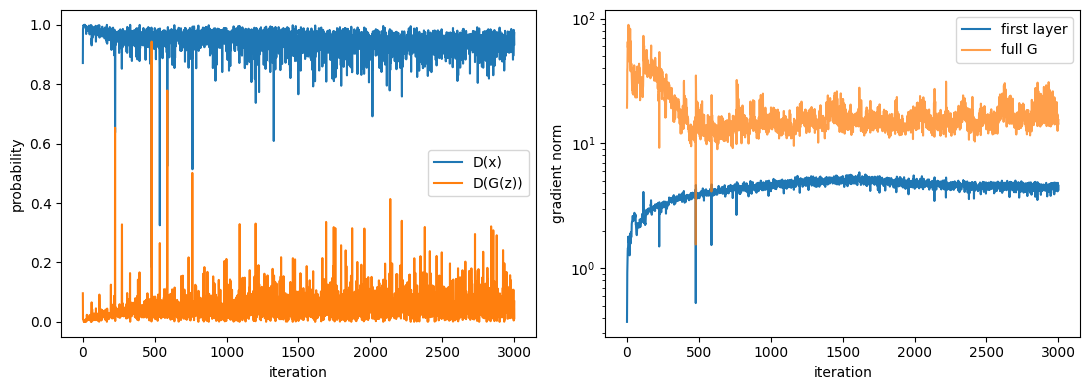

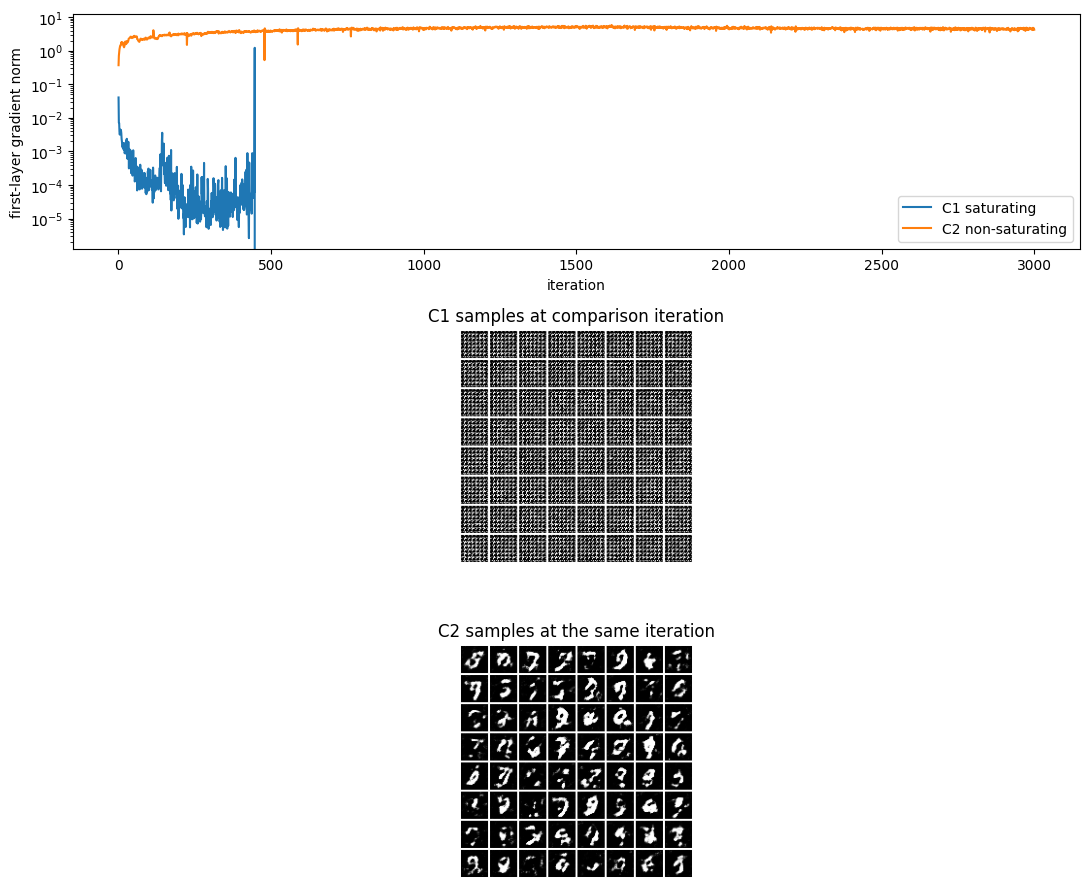

In [28]:
if RUN_FULL:
    G_C2, D_C2, log_C2, snaps_C2, _, _ = logistic_gan_run(
        "C2", gan_loader, zdim=64, iterations=3000, d_steps=5, g_steps=1,
        lr_d=8e-4, lr_g=2e-4, saturating=False,
        capture_iteration=c1_death)
    c1_compare = snaps_C1.get("death", snaps_C1["final"])
    c2_compare = snaps_C2.get("matched", snaps_C2["final"])
    fig, axes = plt.subplots(3, 1, figsize=(11, 9))
    axes[0].plot(log_C1["iter"], log_C1["g_grad_norm"], label="C1 saturating")
    axes[0].plot(log_C2["iter"], log_C2["g_grad_norm"], label="C2 non-saturating")
    axes[0].set_yscale("log"); axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("first-layer gradient norm"); axes[0].legend()
    for ax, images, title in [
        (axes[1], c1_compare, "C1 samples at comparison iteration"),
        (axes[2], c2_compare, "C2 samples at the same iteration"),
    ]:
        grid = torchvision.utils.make_grid(to_01(images).clamp(0, 1), nrow=8,
                                           padding=2, pad_value=1)
        ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.savefig(ROOT / "figures" / "C2_overlay.png", dpi=160)
    plt.show()
    append_diary("C2", "same C1 setup; only generator loss changed")


### Classifier-based mode measurements


In [29]:
@torch.no_grad()
def classify(clf, images, batch_size=500):
    clf.eval(); probabilities, features = [], []
    for start in range(0, len(images), batch_size):
        x = images[start:start + batch_size].to(DEV)
        f = clf.features(x)
        p = clf.head(f).softmax(1)
        probabilities.append(p.cpu().numpy())
        features.append(f.cpu().numpy())
    return np.concatenate(probabilities), np.concatenate(features)


def mode_stats(probabilities, tol=0.01):
    predicted = probabilities.argmax(1)
    counts = np.bincount(predicted, minlength=len(MY_DIGITS))
    proportions = counts / counts.sum()
    modes = int((proportions >= tol).sum())
    uniform = np.full(len(MY_DIGITS), 1 / len(MY_DIGITS))
    nonzero = proportions > 0
    reverse_kl = float(np.sum(proportions[nonzero] *
                              np.log(proportions[nonzero] / uniform[nonzero])))
    return predicted, counts, proportions, modes, reverse_kl


@torch.no_grad()
def collect_samples(generator, n, zdim, seed, batch_size=500):
    generator.eval()
    cpu_generator = torch.Generator().manual_seed(seed)
    chunks = []
    while sum(len(chunk) for chunk in chunks) < n:
        size = min(batch_size, n - sum(len(chunk) for chunk in chunks))
        z = torch.randn(size, zdim, generator=cpu_generator).to(DEV)
        chunks.append(to_01(generator(z)).clamp(0, 1).cpu())
    return torch.cat(chunks)


def save_mode_evidence(name, samples, clf):
    probabilities, features = classify(clf, samples)
    predicted, counts, proportions, modes, reverse_kl = mode_stats(probabilities)
    np.save(ROOT / "samples" / f"{name}_predicted_labels.npy", predicted)
    torch.save(samples, ROOT / "samples" / f"{name}_5000.pt")
    rows = [{"class_index": i, "digit": digit, "count": int(counts[i]),
             "proportion": float(proportions[i])}
            for i, digit in enumerate(MY_DIGITS)]
    save_rows(ROOT / "logs" / f"{name}_counts.csv", list(rows[0]), rows)
    plt.figure(figsize=(6, 4))
    plt.bar([str(d) for d in MY_DIGITS], proportions)
    plt.xlabel("predicted digit"); plt.ylabel("generated proportion")
    plt.tight_layout(); plt.savefig(ROOT / "figures" / f"{name}_hist.png", dpi=160)
    plt.show()
    record(f"{name}_modes_covered", modes)
    record(f"{name}_reverse_kl", reverse_kl)
    record(f"{name}_class_proportions", proportions)
    return probabilities, features


### C3. Force and measure collapse


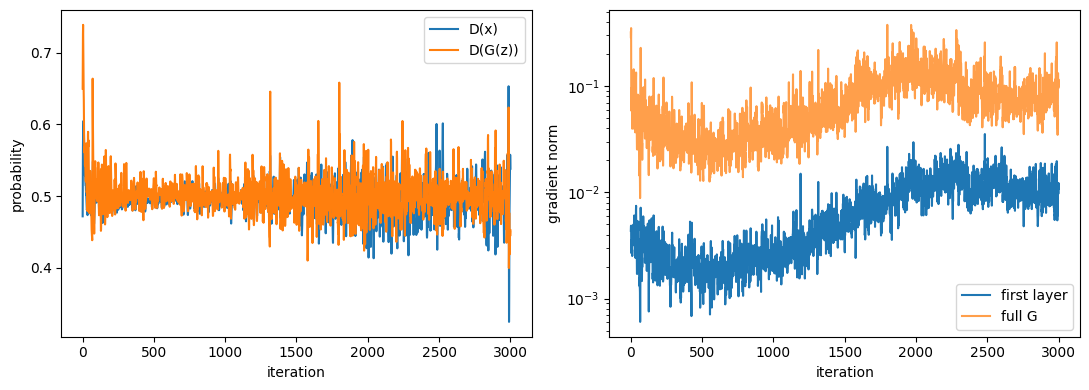

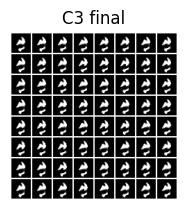

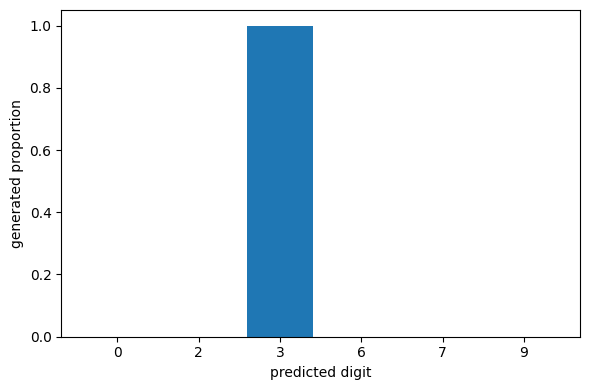

C3_modes_covered = 1
C3_reverse_kl = 1.791759469228055
C3_class_proportions = [0.0, 0.0, 1.0, 0.0, 0.0, 0.0]


In [30]:
if RUN_FULL:
    G_C3, D_C3, log_C3, snaps_C3, _, _ = logistic_gan_run(
        "C3", gan_loader, zdim=2, iterations=3000, d_steps=1, g_steps=5,
        lr_d=2e-4, lr_g=2e-3, saturating=False, g_batchnorm=False)
    save_stacked_rows([snaps_C3["final"]], ["C3 final"],
                      ROOT / "figures" / "C3_samples.png")
    samples_C3 = collect_samples(G_C3, 5000, 2, SEED + 303)
    probs_C3, feats_C3 = save_mode_evidence("C3", samples_C3, clf)
    append_diary("C3", "zdim=2, no G BatchNorm, five G steps per D step")


### D1. Working DCGAN


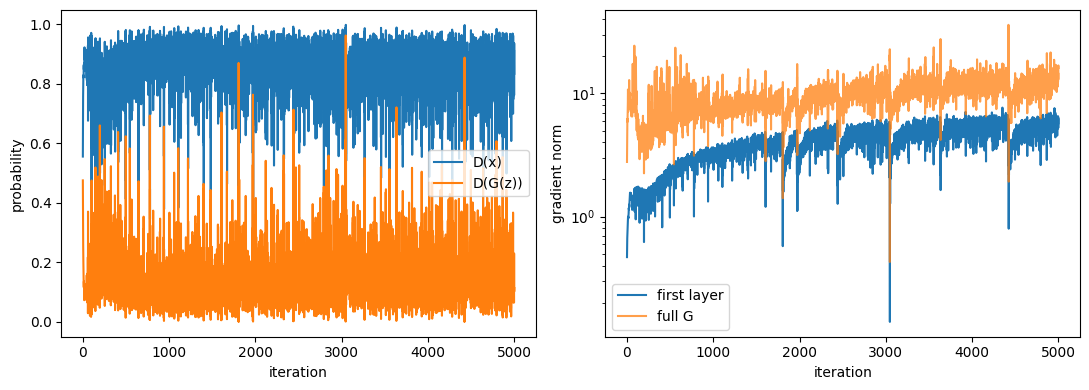

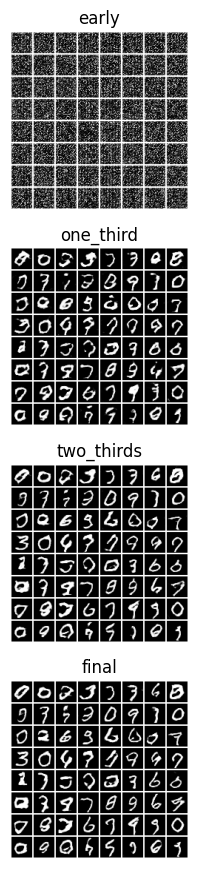

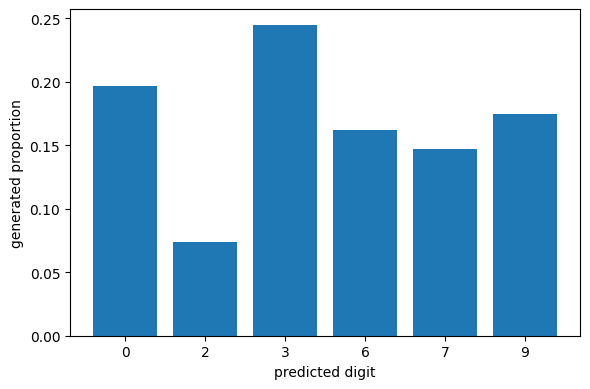

D1_modes_covered = 6
D1_reverse_kl = 0.05277866431621027
D1_class_proportions = [0.197, 0.074, 0.2452, 0.1622, 0.147, 0.1746]


In [31]:
if RUN_FULL:
    G_D1, D_D1, log_D1, snaps_D1, _, _ = logistic_gan_run(
        "D1", gan_loader, zdim=64, iterations=5000, d_steps=1, g_steps=1,
        lr_d=2e-4, lr_g=2e-4, saturating=False,
        g_batchnorm=True, d_batchnorm=True,
        snapshot_points={1: "early", 5000 // 3: "one_third",
                         2 * 5000 // 3: "two_thirds"})
    d1_order = ["early", "one_third", "two_thirds", "final"]
    save_stacked_rows([snaps_D1[key] for key in d1_order], d1_order,
                      ROOT / "figures" / "D1_progress.png")
    samples_D1 = collect_samples(G_D1, 5000, 64, SEED + 401)
    probs_D1, feats_D1 = save_mode_evidence("D1", samples_D1, clf)
    append_diary("D1", "DCGAN, 1:1 updates, BatchNorm in G and D")


### D2. WGAN-GP stabilizer


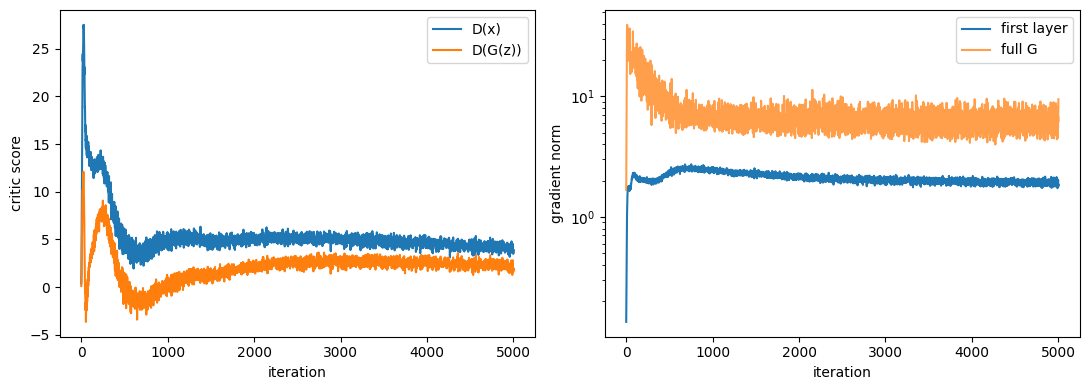

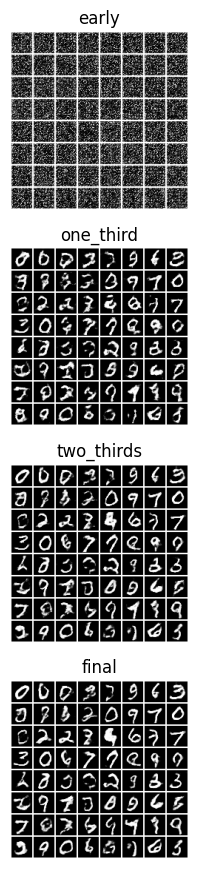

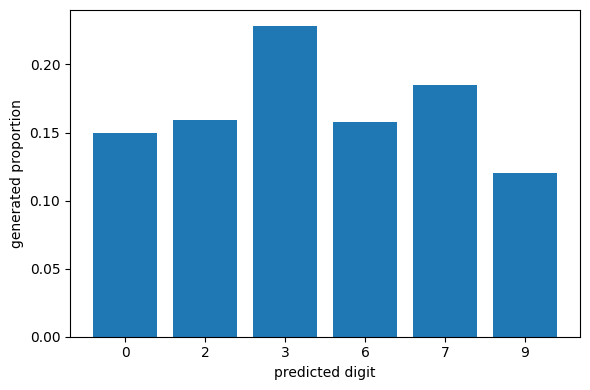

D2_modes_covered = 6
D2_reverse_kl = 0.019803437485144425
D2_class_proportions = [0.1494, 0.1594, 0.2286, 0.1574, 0.185, 0.1202]


In [32]:
def gradient_penalty(critic, real, fake):
    alpha = torch.rand(len(real), 1, 1, 1, device=real.device)
    mixed = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    scores = critic(mixed)
    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=mixed,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    return ((gradients.flatten(1).norm(2, dim=1) - 1) ** 2).mean()


def train_wgan_gp(loader, iterations=5000, zdim=64, critic_steps=5,
                  lr=1e-4, gp_weight=10.0):
    set_seed()
    G = G28(zdim=zdim, batchnorm=True).to(DEV)
    C = D28(batchnorm=False).to(DEV)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    opt_c = torch.optim.Adam(C.parameters(), lr=lr, betas=(0.0, 0.9))
    fixed_z = torch.randn(64, zdim, device=DEV)
    torch.save(fixed_z.cpu(), ROOT / "samples" / "D2_fixed_z.pt")
    log = GANRunLog("D2")
    real_iterator = iter(loader); snapshots = {}
    capture_points = {1: "early", iterations // 3: "one_third",
                      2 * iterations // 3: "two_thirds", iterations: "final"}

    for iteration in range(1, iterations + 1):
        set_requires_grad(C, True)
        for _ in range(critic_steps):
            (real, _), real_iterator = next_real(real_iterator, loader)
            real = to_pm1(real.to(DEV))
            z = torch.randn(len(real), zdim, device=DEV)
            fake = G(z).detach()
            opt_c.zero_grad(set_to_none=True)
            real_score, fake_score = C(real), C(fake)
            gp = gradient_penalty(C, real, fake)
            c_loss = fake_score.mean() - real_score.mean() + gp_weight * gp
            c_loss.backward(); opt_c.step()

        set_requires_grad(C, False)
        opt_g.zero_grad(set_to_none=True)
        generated_score = C(G(torch.randn(loader.batch_size, zdim, device=DEV)))
        g_loss = -generated_score.mean()
        g_loss.backward()
        first_norm, all_norm = first_grad_norm(G.fc), full_grad_norm(G)
        opt_g.step(); set_requires_grad(C, True)
        finite_check("critic_loss", c_loss.item()); finite_check("g_loss", g_loss.item())
        log.write(iter=iteration, d_loss=c_loss.item(), g_loss=g_loss.item(),
                  D_x=real_score.mean().item(), D_G_z=generated_score.mean().item(),
                  g_grad_norm=first_norm, g_full_grad_norm=all_norm,
                  d_steps=critic_steps, g_steps=1)
        if iteration in capture_points:
            with torch.no_grad(): snapshots[capture_points[iteration]] = G(fixed_z).cpu()

    frame = log.close()
    save_checkpoint("D2", G, {"zdim": zdim, "iterations": iterations,
                              "critic_steps": critic_steps, "lr": lr,
                              "gradient_penalty": gp_weight},
                    discriminator_state=C.state_dict())
    plot_gan_curves(frame, "D2", probability_labels=False)
    save_stacked_rows(list(snapshots.values()), list(snapshots.keys()),
                      ROOT / "figures" / "D2_progress.png")
    return G, C, frame


if RUN_FULL:
    G_D2, C_D2, log_D2 = train_wgan_gp(gan_loader)
    samples_D2 = collect_samples(G_D2, 5000, 64, SEED + 402)
    probs_D2, feats_D2 = save_mode_evidence("D2", samples_D2, clf)
    append_diary("D2", "WGAN-GP, five critic steps, lambda=10")


## 6. Part E - IS and FID


/tmp/ipykernel_1803/3605130429.py:22: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(cov_r @ cov_g)


E_real_is_mean = 5.771989051419089
E_real_is_std = 0.026242566072370882
E_real_fid = 1.3986500971225027
E_C1_is_mean = 1.0346990226748434
E_C1_is_std = 0.001089360700439436
E_C1_fid = 941.8811383946675
E_C3_is_mean = 1.0006316276302294
E_C3_is_std = 2.4547116415038207e-05
E_C3_fid = 821.2406439299862
E_D1_is_mean = 4.477211786672068
E_D1_is_std = 0.10802878989524922
E_D1_fid = 39.69995018183848
E_D2_is_mean = 4.618955248016118
E_D2_is_std = 0.08984372931128058
E_D2_fid = 17.11675171921332
    set     n   is_mean    is_std         fid
0  real  5000  5.771989  0.026243    1.398650
1    C1  5000  1.034699  0.001089  941.881138
2    C3  5000  1.000632  0.000025  821.240644
3    D1  5000  4.477212  0.108029   39.699950
4    D2  5000  4.618955  0.089844   17.116752


/tmp/ipykernel_1803/3605130429.py:22: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(cov_r @ cov_g)


E3_fid_floor = 1.200874296034537


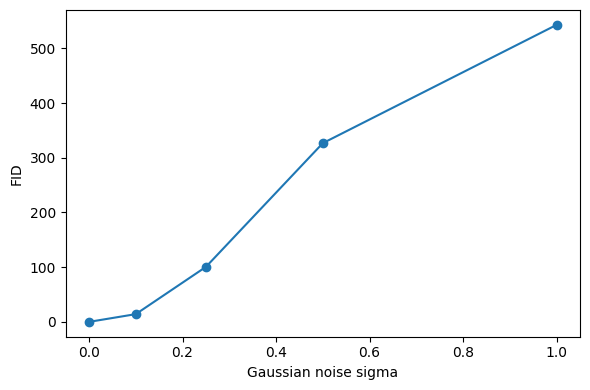

E3_noise_fid = [{'sigma': 0.0, 'fid': 4.8396749930346045e-09}, {'sigma': 0.1, 'fid': 14.143732241352097}, {'sigma': 0.25, 'fid': 100.55164912897257}, {'sigma': 0.5, 'fid': 326.750243434809}, {'sigma': 1.0, 'fid': 543.035565084177}]
E_fid_diagnostics = [{'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsilon_retry': False, 'initial_max_imaginary': 0.0, 'epsilon': 1e-06}, {'epsil

In [33]:
def inception_score(probabilities, splits=10, eps=1e-12):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    chunks = np.array_split(probabilities, splits)
    scores = []
    for chunk in chunks:
        p_yx = np.clip(chunk, eps, 1.0)
        p_y = np.clip(p_yx.mean(0, keepdims=True), eps, 1.0)
        mean_kl = np.sum(p_yx * (np.log(p_yx) - np.log(p_y)), axis=1).mean()
        scores.append(float(np.exp(mean_kl)))
    return float(np.mean(scores)), float(np.std(scores)), scores


FID_DIAGNOSTICS = []


def frechet_distance(feat_real, feat_gen, eps=1e-6):
    real = np.asarray(feat_real, dtype=np.float64)
    generated = np.asarray(feat_gen, dtype=np.float64)
    mu_r, mu_g = real.mean(0), generated.mean(0)
    cov_r = np.cov(real, rowvar=False)
    cov_g = np.cov(generated, rowvar=False)
    covmean = linalg.sqrtm(cov_r @ cov_g)
    used_epsilon_retry = False
    initial_imaginary = (float(np.abs(covmean.imag).max())
                         if np.iscomplexobj(covmean) else 0.0)
    if (not np.isfinite(covmean).all()) or initial_imaginary > 1e-3:
        identity = np.eye(cov_r.shape[0]) * eps
        covmean = linalg.sqrtm((cov_r + identity) @ (cov_g + identity))
        used_epsilon_retry = True
    if np.iscomplexobj(covmean):
        max_imaginary = float(np.abs(covmean.imag).max())
        if max_imaginary > 1e-3:
            raise ValueError(f"large imaginary sqrtm component: {max_imaginary}")
        covmean = covmean.real
    distance = np.sum((mu_r - mu_g) ** 2) + np.trace(cov_r + cov_g - 2 * covmean)
    if not np.isfinite(distance):
        raise FloatingPointError("FID is not finite")
    FID_DIAGNOSTICS.append({"epsilon_retry": used_epsilon_retry,
                            "initial_max_imaginary": initial_imaginary,
                            "epsilon": eps})
    return float(max(distance, 0.0))


def fixed_real_subset(dataset, digits, n, seed):
    subset = subset_by_digits(dataset, digits)
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(subset), min(n, len(subset)), replace=False)
    images = torch.stack([subset[int(i)][0] for i in chosen])
    return images, chosen


def evaluate_e1_e2(clf, sets, real_reference_features):
    summary_rows, split_rows = [], []
    for name, images in sets.items():
        probabilities, features = classify(clf, images)
        is_mean, is_std, split_scores = inception_score(probabilities)
        fid = frechet_distance(real_reference_features, features)
        summary_rows.append({"set": name, "n": len(images), "is_mean": is_mean,
                             "is_std": is_std, "fid": fid})
        split_rows.extend({"set": name, "split": i, "is": score}
                          for i, score in enumerate(split_scores))
        record(f"E_{name}_is_mean", is_mean)
        record(f"E_{name}_is_std", is_std)
        record(f"E_{name}_fid", fid)
    save_rows(ROOT / "logs" / "E_summary.csv", list(summary_rows[0]), summary_rows)
    save_rows(ROOT / "logs" / "E1_split_scores.csv", list(split_rows[0]), split_rows)
    return pd.DataFrame(summary_rows)


def run_e3(clf, real_test_images):
    midpoint = len(real_test_images) // 2
    _, feat_a = classify(clf, real_test_images[:midpoint])
    _, feat_b = classify(clf, real_test_images[midpoint:2 * midpoint])
    floor = frechet_distance(feat_a, feat_b)
    record("E3_fid_floor", floor)

    base = real_test_images[:min(5000, len(real_test_images))]
    generator = torch.Generator().manual_seed(SEED + 909)
    base_noise = torch.randn(base.shape, generator=generator)
    _, clean_features = classify(clf, base)
    rows = []
    for sigma in [0.0, 0.1, 0.25, 0.5, 1.0]:
        noisy = (base + sigma * base_noise).clamp(0, 1)
        _, noisy_features = classify(clf, noisy)
        rows.append({"sigma": sigma,
                     "fid": frechet_distance(clean_features, noisy_features)})
    save_rows(ROOT / "logs" / "E3_noise_fid.csv", ["sigma", "fid"], rows)
    plt.figure(figsize=(6, 4))
    plt.plot([row["sigma"] for row in rows], [row["fid"] for row in rows], marker="o")
    plt.xlabel("Gaussian noise sigma"); plt.ylabel("FID")
    plt.tight_layout(); plt.savefig(ROOT / "figures" / "E3_noise_fid.png", dpi=160)
    plt.show()
    record("E3_noise_fid", rows)


if RUN_FULL:
    real_test, real_test_indices = fixed_real_subset(mnist_te, MY_DIGITS, 5000, SEED + 701)
    real_test_all, real_test_all_indices = fixed_real_subset(
        mnist_te, MY_DIGITS, len(mnist_te), SEED + 703)
    real_train, real_train_indices = fixed_real_subset(mnist_tr, MY_DIGITS, 5000, SEED + 702)
    np.save(ROOT / "data" / "E_real_test_indices.npy", real_test_indices)
    np.save(ROOT / "data" / "E3_real_test_all_indices.npy", real_test_all_indices)
    np.save(ROOT / "data" / "E_real_train_reference_indices.npy", real_train_indices)
    _, real_reference_features = classify(clf, real_train)

    samples_C1 = collect_samples(G_C1, 5000, 64, SEED + 301)
    torch.save(samples_C1, ROOT / "samples" / "C1_5000.pt")
    probs_C1, feats_C1 = classify(clf, samples_C1)

    evaluation_sets = {
        "real": real_test,
        "C1": samples_C1,
        "C3": samples_C3,
        "D1": samples_D1,
        "D2": samples_D2,
    }
    final_table = evaluate_e1_e2(clf, evaluation_sets, real_reference_features)
    print(final_table)
    comparison_rows = [{
        "model": name,
        "modes_covered": METRICS[f"{name}_modes_covered"],
        "reverse_kl": METRICS[f"{name}_reverse_kl"],
        "is_mean": METRICS[f"E_{name}_is_mean"],
        "fid": METRICS[f"E_{name}_fid"],
    } for name in ["C3", "D1", "D2"]]
    save_rows(ROOT / "logs" / "final_model_comparison.csv",
              list(comparison_rows[0]), comparison_rows)
    run_e3(clf, real_test_all)
    record("E_fid_diagnostics", FID_DIAGNOSTICS)
    append_diary("Part_E", "IS/FID and two FID sanity checks")


## 7. Evidence and package validation


In [34]:
def validate_csv(path, required_columns):
    frame = pd.read_csv(path)
    missing = set(required_columns) - set(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")
    numeric = frame.select_dtypes(include=[np.number])
    if len(frame) == 0:
        raise ValueError(f"{path}: empty CSV")
    if not np.isfinite(numeric.to_numpy()).all():
        raise ValueError(f"{path}: NaN or Inf detected")
    return len(frame)


def validate_package():
    required_files = [
        "metrics.json", "run_config.json",
        "figures/A1_recon.png", "figures/A2_vae_interp.png",
        "figures/A3_prior_samples.png", "figures/B1_denoise.png",
        "figures/C1_samples.png", "figures/C2_overlay.png",
        "figures/C3_hist.png", "figures/D1_progress.png",
        "figures/D2_progress.png", "figures/E3_noise_fid.png",
        "logs/C1.csv", "logs/C2.csv", "logs/C3.csv",
        "logs/D1.csv", "logs/D2.csv", "logs/E_summary.csv",
    ]
    missing = [name for name in required_files if not (ROOT / name).exists()]
    if missing:
        print("Missing artifacts:")
        for name in missing:
            print(" -", name)
    else:
        print("All expected run artifacts exist.")

    gan_columns = ["iter", "d_loss", "g_loss", "D_x", "D_G_z",
                   "g_grad_norm", "g_full_grad_norm"]
    for name in ["C1", "C2", "C3", "D1", "D2"]:
        path = ROOT / "logs" / f"{name}.csv"
        if path.exists():
            print(path.name, validate_csv(path, gan_columns), "rows")
    return missing


if RUN_FULL:
    package_missing = validate_package()
    if package_missing:
        print("Do not prepare the final report until missing evidence is resolved.")


All expected run artifacts exist.
C1.csv 3000 rows
C2.csv 3000 rows
C3.csv 3000 rows
D1.csv 5000 rows
D2.csv 5000 rows


## 8. Final student checks

- Open every CSV used in the report and identify the exact supporting row.
- Generate plots and tables from raw artifacts; never retype results.
- Complete each experiment-diary entry using actual observations.
- Use the troubleshooting order: curves, shapes/ranges, ten-image overfit, then
  architecture changes.
- Keep failed runs and explain any change from the planned configuration.
- Do not invent the absent A4, B2, or Part F.
- Confirm the final notebook filename with the instructor/Classroom instruction.
- Export the report only after the package validator passes.
